# 23 — What Rank Does to Evaluation

Every notebook in this project touches rank effects, but each one frames them differently.
This notebook puts them all on one page so the story is clear.

**The story:** As users scan down a SERP, they spend *less time* on each result and invest
*less cognitive effort per fixation* — but the effort drops *faster* than the time.
This is not declining interest — it's compiled evaluation criteria.
The first few results are expensive because the user is building a comparison framework
from scratch. By position 3–4, criteria are compiled: each subsequent result is evaluated against
a well-formed standard, so fewer fixations are needed and each one requires less cognitive work.

**Five measures, one x-axis (result position 0–9, plus click position 10 where applicable):**

| Measure | Direction | Source notebook | What it tells us |
|---------|-----------|-----------------|------------------|
| Click share | Declining (+ boundary uptick) | 00_skijump | Attention allocation under diminishing returns |
| Fixation count | Declining | 06_orientation_evaluation | Fewer looks — the allocation decision |
| Total dwell time | Declining | 06_orientation_evaluation | Less total time invested |
| Butterworth LF/HF | Declining (steep 0–3, plateau) | 14_butterworth | Cognitive effort peaks during framework construction |
| LHIPA (by click depth) | Declining | 05_lhipa | Deeper foraging = more total comparison work |

The user isn't losing interest. They're getting better at the task within a single scan.

In [1]:
from data_loader import *
import json
import numpy as np
from collections import defaultdict
from bisect import bisect_right
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

setup_plotting()

# ── Load all data sources ──────────────────────────────────────────────

trial_ids = get_trial_ids()
lhipa_data = load_lhipa()

with open(DATA_DIR / 'butterworth-lfhf-by-position.json') as f:
    bw_data = json.load(f)

print(f'{len(trial_ids)} trials, {len(lhipa_data)} with LHIPA, {len(bw_data)} with Butterworth')

2776 trials, 2721 with LHIPA, 2719 with Butterworth


In [2]:
# ── Compute per-position evaluation metrics ───────────────────────────
# Duplicates the computation from 06_orientation_evaluation, which is fine —
# this notebook is a unified view, not a downstream consumer.

print('Computing per-position fixation metrics...')

eval_rows = []  # one row per (trial, position)
click_positions = []  # one per trial

for tid in trial_ids:
    t = load_trial(tid)
    if t is None:
        continue

    fixations = t['fixations']
    scr_h = t['screen_height']
    doc_h = t['doc_height']
    sts = t['scroll_ts']
    sys_ = t['scroll_ys']

    # Compute result band tops (same as NB06)
    bands = result_bands(10, doc_h)
    tops = [b[0] for b in bands]

    # Determine clicked position from mouse click events
    # events are (t, event_type, x, y); clicks are (t, x, y)
    clicks = t['clicks']
    if clicks:
        click_t, click_x, click_y = clicks[0]
        so_click = 0.0
        if sts:
            if click_t <= sts[0]: so_click = sys_[0]
            elif click_t >= sts[-1]: so_click = sys_[-1]
            else: so_click = sys_[bisect_right(sts, click_t) - 1]
        clicked_pos = bisect_right(tops, min(click_y, scr_h) + so_click) - 1
        clicked_pos = max(0, min(clicked_pos, 10))
        click_positions.append(clicked_pos)
    else:
        clicked_pos = None

    per_result = defaultdict(lambda: {'fix_count': 0, 'fix_total_ms': 0, 'fix_durations': []})

    for fix in fixations:
        fy = max(0.0, min(fix['y'], scr_h))
        so = 0.0
        if sts:
            if fix['t'] <= sts[0]: so = sys_[0]
            elif fix['t'] >= sts[-1]: so = sys_[-1]
            else: so = sys_[bisect_right(sts, fix['t']) - 1]

        page_y = fy + so
        pos = bisect_right(tops, page_y) - 1
        if 0 <= pos <= 10:
            r = per_result[pos]
            r['fix_count'] += 1
            r['fix_total_ms'] += fix['d']
            r['fix_durations'].append(fix['d'])

    for pos in range(11):
        r = per_result.get(pos)
        if r is None or r['fix_count'] == 0:
            continue
        eval_rows.append({
            'trial': tid,
            'position': pos,
            'fix_count': r['fix_count'],
            'fix_total_ms': r['fix_total_ms'],
            'mean_fix_duration': np.mean(r['fix_durations']),
        })

print(f'{len(eval_rows)} (trial, position) rows from {len(click_positions)} trials with clicks')

Computing per-position fixation metrics...


16335 (trial, position) rows from 2775 trials with clicks


In [3]:
# ── Compute position-level summaries ───────────────────────────────────

# Fixation data covers positions 0–9 (10 results in result_bands).
# Click share, Butterworth, and LHIPA can include position 10.
fix_positions = list(range(10))
all_positions = list(range(11))

# 1. Click share by position (0–10)
click_counts = np.zeros(11)
for cp in click_positions:
    if 0 <= cp <= 10:
        click_counts[cp] += 1
click_share = 100 * click_counts / click_counts.sum()

# 2. Fixation count by position (0–9)
fc_means = [np.mean([r['fix_count'] for r in eval_rows if r['position'] == p]) for p in fix_positions]

# 3. Total dwell time by position (0–9)
dwell_means = [np.mean([r['fix_total_ms'] for r in eval_rows if r['position'] == p]) for p in fix_positions]

# 4. Butterworth LF/HF by position (higher = more cognitive load)
bw_pos_values = defaultdict(list)
for tid, trial in bw_data.items():
    for p in trial['positions']:
        if p['lfhf'] is not None and 0 <= p['pos'] <= 10:
            bw_pos_values[p['pos']].append(p['lfhf'])

bw_medians = [np.median(bw_pos_values[p]) if bw_pos_values[p] else np.nan for p in all_positions]

# 5. Trial-level LHIPA by click position (lower = more load)
def get_lhipa_val(v):
    return v.get('lhipa', v) if isinstance(v, dict) else v

lhipa_by_click_pos = defaultdict(list)
for tid, trial in bw_data.items():
    click_pos = trial.get('click_pos')
    if click_pos is None or tid not in lhipa_data:
        continue
    lv = get_lhipa_val(lhipa_data[tid])
    if lv is not None and 0 <= click_pos <= 10:
        lhipa_by_click_pos[click_pos].append(float(lv))

lhipa_medians = [np.median(lhipa_by_click_pos[p]) if lhipa_by_click_pos[p] else np.nan for p in all_positions]

# Print position-level table
print(f'{"Pos":>4} {"Click%":>7} {"FixCnt":>7} {"Dwell(s)":>9} {"LF/HF":>7} {"LHIPA":>7}')
print('-' * 50)
for p in all_positions:
    fc = f'{fc_means[p]:.1f}' if p < len(fc_means) else '—'
    dw = f'{dwell_means[p]/1000:.2f}' if p < len(dwell_means) else '—'
    bw = f'{bw_medians[p]:.1f}' if not np.isnan(bw_medians[p]) else '—'
    lh = f'{lhipa_medians[p]:.3f}' if not np.isnan(lhipa_medians[p]) else '—'
    print(f'{p:>4} {click_share[p]:>7.1f} {fc:>7} {dw:>9} {bw:>7} {lh:>7}')

print('\nPosition summaries computed.')

 Pos  Click%  FixCnt  Dwell(s)   LF/HF   LHIPA
--------------------------------------------------
   0    20.6    19.9      4.24    30.0   0.039
   1    16.8    14.2      3.18    21.2   0.039
   2    17.1    10.6      2.37    18.3   0.039
   3    13.3    10.0      2.21    16.0   0.039
   4    10.1     9.9      2.22    16.3   0.039
   5     8.9    10.9      2.47    18.7   0.039
   6     5.3    10.6      2.35    18.2   0.038
   7     3.1    10.0      2.19    17.1   0.039
   8     2.3     7.8      1.73    16.8   0.039
   9     2.5    12.2      2.63    15.9   0.038
  10     0.0       —         —    16.5   0.038

Position summaries computed.


## The unified view

Five panels, one x-axis. Read top to bottom:

1. **Click share** drops with position — the well-known rank effect. Uptick at position 10 is the boundary/ski-jump.
2. **Fixation count** drops — users allocate fewer looks to lower results.
3. **Total dwell** drops — less total time spent on each successive result.
4. **Butterworth LF/HF** drops — this is the key. Higher LF/HF = higher cognitive load. Load is *highest* at position 0 where the user is constructing evaluation criteria from scratch. By position 3–4, criteria are compiled and load plateaus.
5. **LHIPA by click position** — essentially flat from positions 0–8, then steps down at 9–10. This is NOT a gradual rank effect — it's the boundary decision cost (same phenomenon as the ski-jump in panel 1). The rho = -0.87 is driven almost entirely by the boundary step, not by a position gradient.

Panels 2–3 say "less time." Panel 4 says "less cognitive effort (compiled criteria)." Panel 5 says the *trial-level* load is constant regardless of where you click — unless you click at the boundary, where the decision is hardest.

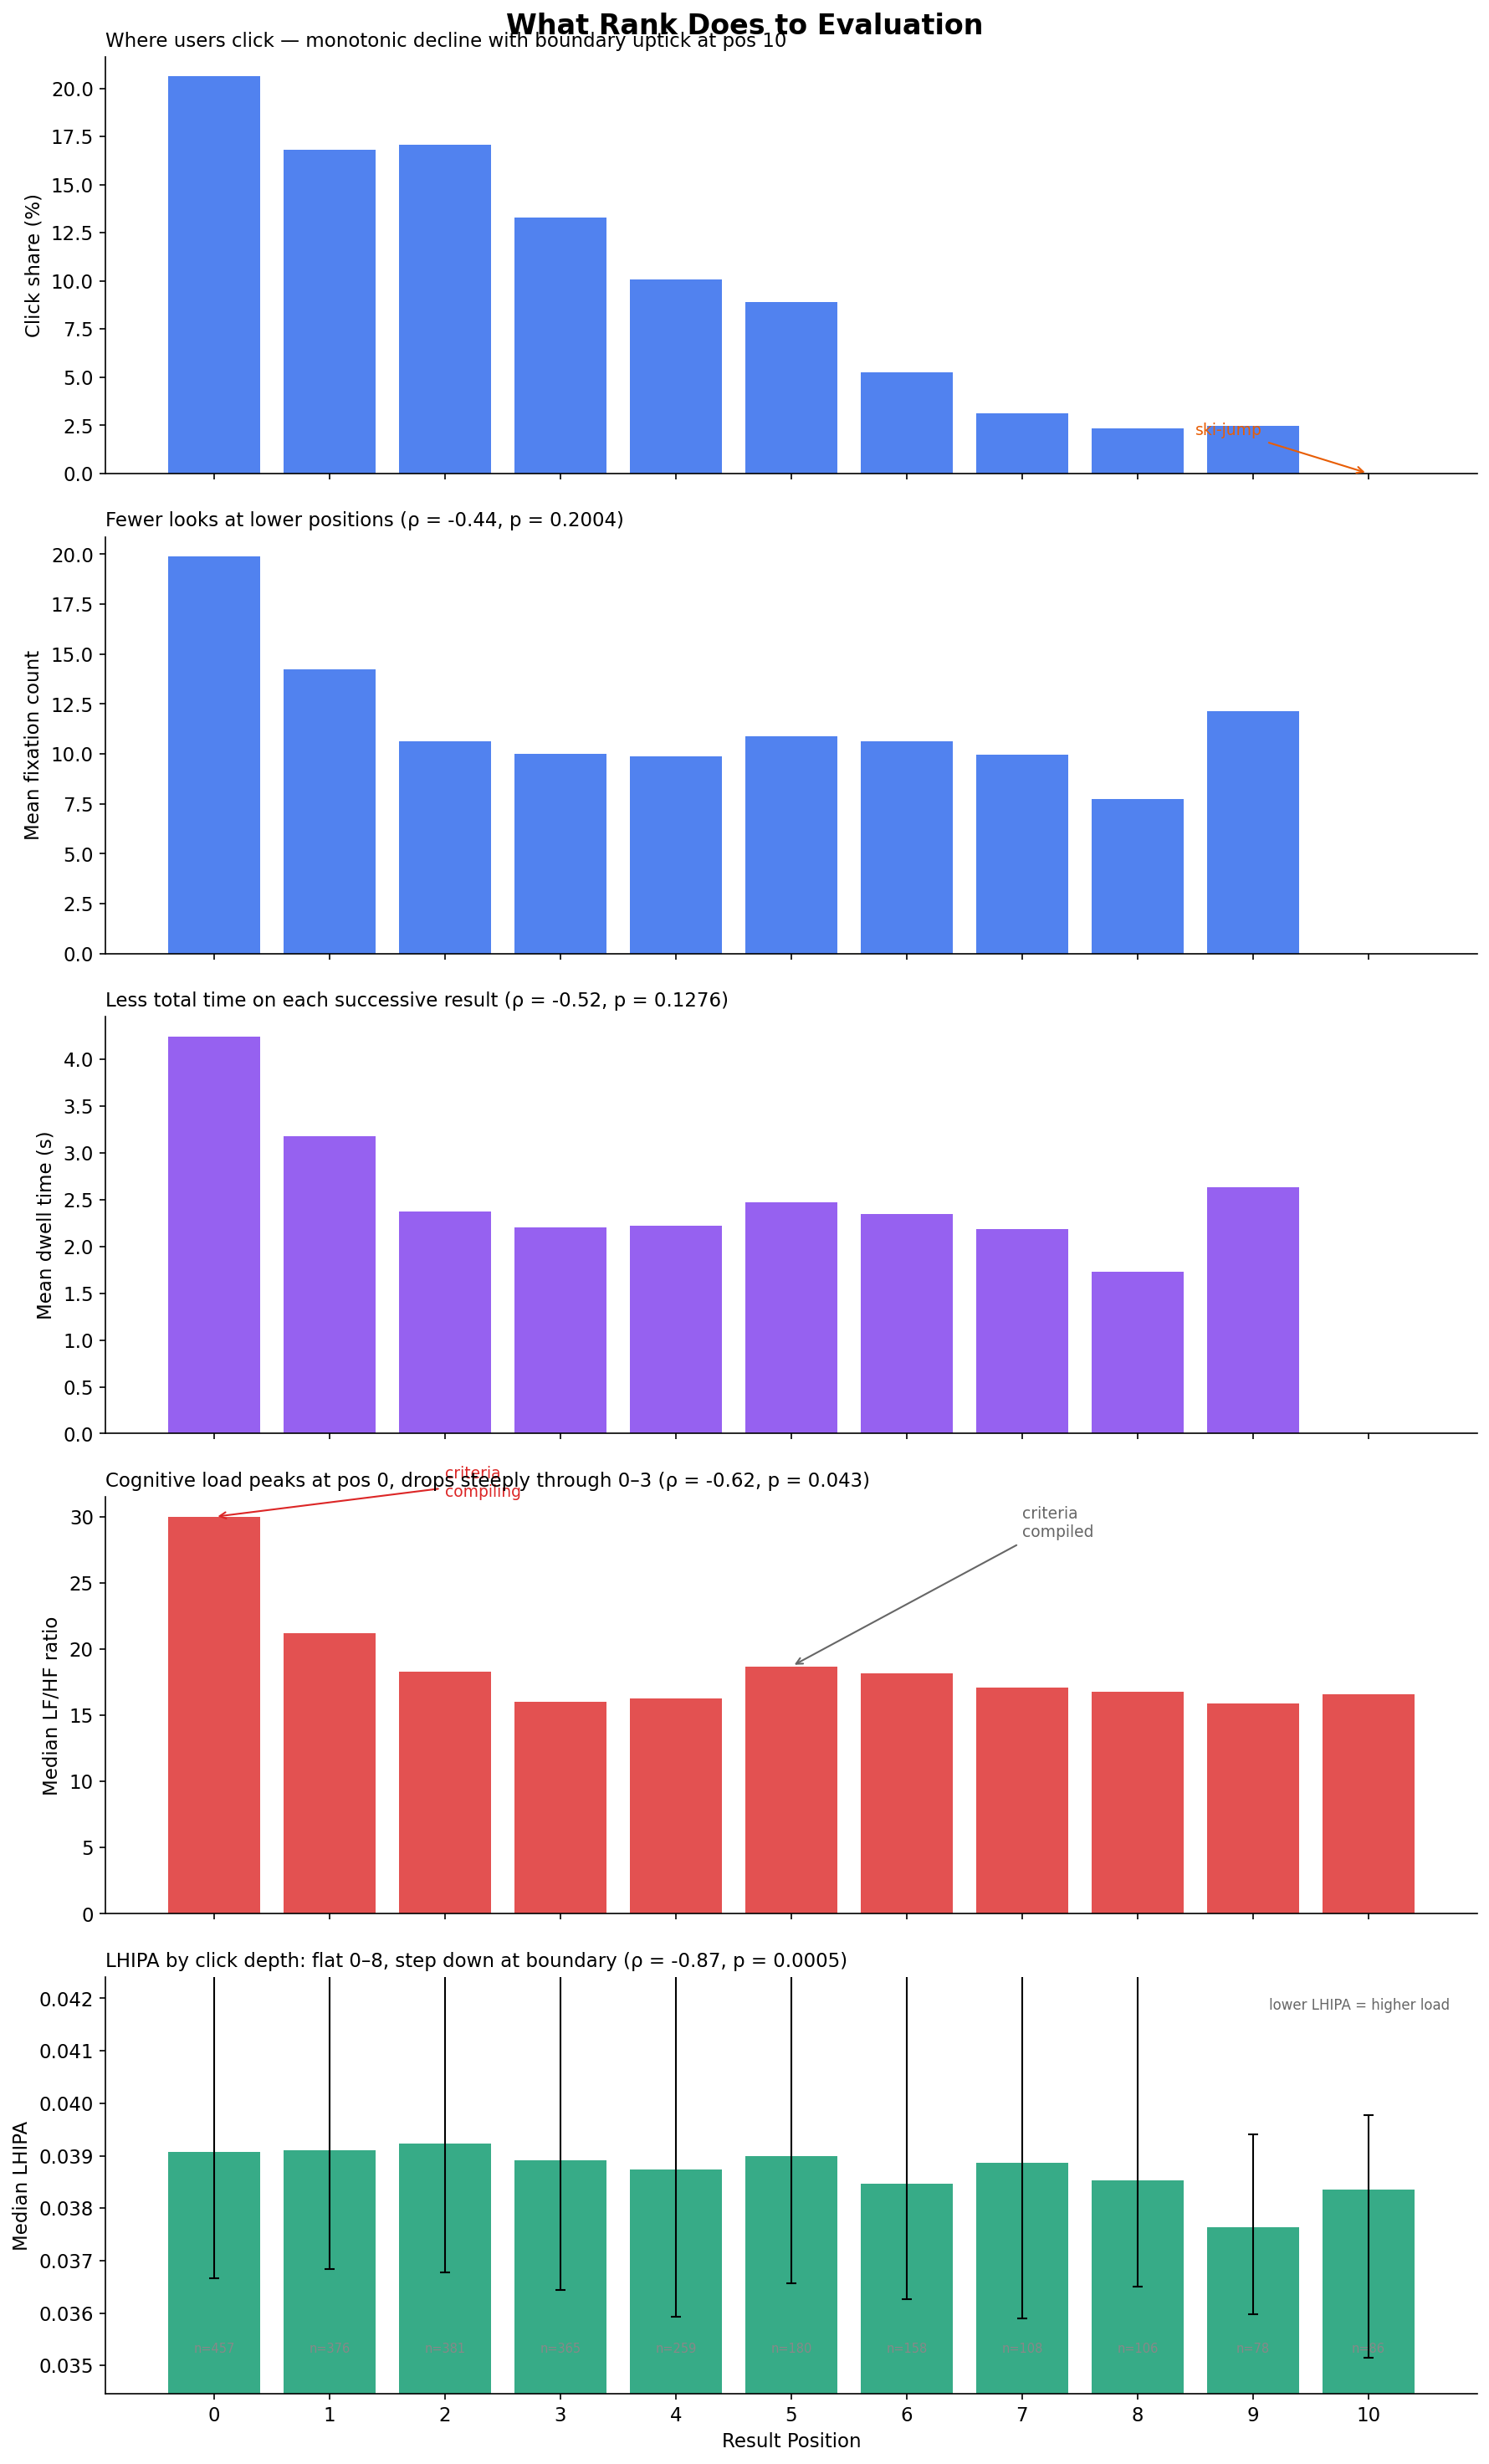


Correlation summary (all Spearman):
  Click share × position (0–10):    ρ = -0.982  (p = 8.40e-08)
  Fixation count × position (0–9):  ρ = -0.442  (p = 0.2004)
  Dwell time × position (0–9):      ρ = -0.515  (p = 0.1276)
  Butterworth LF/HF × position:     ρ = -0.618  (p = 0.0426)
  LHIPA × click position (0–10):    ρ = -0.873  (p = 0.0005)
  LHIPA × click position (0–8):     ρ = -0.783  (p = 0.0125)  ← boundary excluded

  LHIPA range: 0.0376 to 0.0392 (delta = 0.0016)
  Positions 0–8 range: 0.0385 to 0.0392 (delta = 0.0008)
  Boundary drop (pos 9–10 vs 0–8): 0.0389 vs 0.0380


In [4]:
# ── Unified rank-effects figure ────────────────────────────────────────

fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)
fig.suptitle('What Rank Does to Evaluation', fontsize=16, fontweight='bold', y=0.98)

bar_kw = dict(alpha=0.8, edgecolor='none')

# ── Panel 1: Click share (0–10) ───────────────────────────────────────
ax = axes[0]
colors_click = ['#e85d04' if p == 10 else '#2563eb' for p in all_positions]
ax.bar(all_positions, click_share, color=colors_click, **bar_kw)
ax.set_ylabel('Click share (%)')
ax.set_title('Where users click — monotonic decline with boundary uptick at pos 10',
             fontsize=11, loc='left')
ax.annotate('ski-jump', xy=(10, click_share[10]), xytext=(8.5, click_share[10] + 2),
            arrowprops=dict(arrowstyle='->', color='#e85d04'), fontsize=9, color='#e85d04')

# ── Panel 2: Fixation count (0–9) ─────────────────────────────────────
ax = axes[1]
ax.bar(fix_positions, fc_means, color='#2563eb', **bar_kw)
rho_fc, p_fc = spearmanr(fix_positions, fc_means)
ax.set_ylabel('Mean fixation count')
ax.set_title(f'Fewer looks at lower positions (\u03c1 = {rho_fc:.2f}, p = {p_fc:.4f})',
             fontsize=11, loc='left')

# ── Panel 3: Total dwell time (0–9) ───────────────────────────────────
ax = axes[2]
dwell_s = [d / 1000 for d in dwell_means]
ax.bar(fix_positions, dwell_s, color='#7c3aed', **bar_kw)
rho_dw, p_dw = spearmanr(fix_positions, dwell_s)
ax.set_ylabel('Mean dwell time (s)')
ax.set_title(f'Less total time on each successive result (\u03c1 = {rho_dw:.2f}, p = {p_dw:.4f})',
             fontsize=11, loc='left')

# ── Panel 4: Butterworth LF/HF (cognitive load) ───────────────────────
ax = axes[3]
valid_bw = [(p, m) for p, m in zip(all_positions, bw_medians) if not np.isnan(m)]
bw_pos, bw_vals = zip(*valid_bw)
ax.bar(bw_pos, bw_vals, color='#dc2626', **bar_kw)
rho_bw, p_bw = spearmanr(bw_pos, bw_vals)
ax.set_ylabel('Median LF/HF ratio')
ax.set_title(f'Cognitive load peaks at pos 0, drops steeply through 0\u20133 (\u03c1 = {rho_bw:.2f}, p = {p_bw:.3f})',
             fontsize=11, loc='left')
ax.annotate('criteria\ncompiling', xy=(0, bw_vals[0]), xytext=(2, bw_vals[0] * 1.05),
            arrowprops=dict(arrowstyle='->', color='#dc2626'), fontsize=9, color='#dc2626')
ax.annotate('criteria\ncompiled', xy=(5, bw_vals[5] if len(bw_vals) > 5 else bw_vals[-1]),
            xytext=(7, bw_vals[0] * 0.95),
            arrowprops=dict(arrowstyle='->', color='#666'), fontsize=9, color='#666')

# ── Panel 5: LHIPA by click position ──────────────────────────────────
# IMPORTANT: zoomed y-axis. The absolute range is ~0.037–0.040, so a zero
# baseline makes it look flat. The actual pattern is flat 0–8 with a step
# down at 9–10 — a boundary decision cost, not a gradual rank effect.
ax = axes[4]
valid_lh = [(p, m) for p, m in zip(all_positions, lhipa_medians) if not np.isnan(m)]
lh_pos, lh_vals = zip(*valid_lh)

# Compute IQR for error bars
lh_q25 = [np.percentile(lhipa_by_click_pos[p], 25) if lhipa_by_click_pos[p] else np.nan for p in lh_pos]
lh_q75 = [np.percentile(lhipa_by_click_pos[p], 75) if lhipa_by_click_pos[p] else np.nan for p in lh_pos]
lh_err_lo = [v - q for v, q in zip(lh_vals, lh_q25)]
lh_err_hi = [q - v for v, q in zip(lh_vals, lh_q75)]

ax.bar(lh_pos, lh_vals, yerr=[lh_err_lo, lh_err_hi], color='#059669',
       capsize=3, error_kw={'linewidth': 1, 'color': '#333'}, **bar_kw)
rho_lh, p_lh = spearmanr(lh_pos, lh_vals)

# Zoom y-axis to show actual variation
lh_min = min(lh_vals)
lh_max = max(lh_vals)
lh_range = lh_max - lh_min
ax.set_ylim(lh_min - lh_range * 2, lh_max + lh_range * 2)

ax.set_ylabel('Median LHIPA')
ax.set_title(f'LHIPA by click depth: flat 0\u20138, step down at boundary (\u03c1 = {rho_lh:.2f}, p = {p_lh:.4f})',
             fontsize=11, loc='left')
ax.set_xlabel('Result Position')
ax.annotate('lower LHIPA = higher load', xy=(0.98, 0.95), xycoords='axes fraction',
            fontsize=8, ha='right', va='top', color='#666')

# Count annotations
lh_counts = [len(lhipa_by_click_pos[p]) for p in lh_pos]
for i, (p, v, n) in enumerate(zip(lh_pos, lh_vals, lh_counts)):
    ax.text(p, lh_min - lh_range * 1.5, f'n={n}', ha='center', fontsize=7, color='#888')

for ax in axes:
    ax.set_xticks(all_positions)

plt.tight_layout()
plt.savefig('plot_rank_effects_unified.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats — boundary decomposition
rho_lh_08, p_lh_08 = spearmanr(list(range(9)), lh_vals[:9])
rho_cs, p_cs = spearmanr(all_positions, click_share)

print(f'\nCorrelation summary (all Spearman):')
print(f'  Click share \u00d7 position (0\u201310):    \u03c1 = {rho_cs:.3f}  (p = {p_cs:.2e})')
print(f'  Fixation count \u00d7 position (0\u20139):  \u03c1 = {rho_fc:.3f}  (p = {p_fc:.4f})')
print(f'  Dwell time \u00d7 position (0\u20139):      \u03c1 = {rho_dw:.3f}  (p = {p_dw:.4f})')
print(f'  Butterworth LF/HF \u00d7 position:     \u03c1 = {rho_bw:.3f}  (p = {p_bw:.4f})')
print(f'  LHIPA \u00d7 click position (0\u201310):    \u03c1 = {rho_lh:.3f}  (p = {p_lh:.4f})')
print(f'  LHIPA \u00d7 click position (0\u20138):     \u03c1 = {rho_lh_08:.3f}  (p = {p_lh_08:.4f})  \u2190 boundary excluded')
print(f'\n  LHIPA range: {min(lh_vals):.4f} to {max(lh_vals):.4f} (delta = {max(lh_vals)-min(lh_vals):.4f})')
print(f'  Positions 0\u20138 range: {min(lh_vals[:9]):.4f} to {max(lh_vals[:9]):.4f} (delta = {max(lh_vals[:9])-min(lh_vals[:9]):.4f})')
print(f'  Boundary drop (pos 9\u201310 vs 0\u20138): {np.mean(lh_vals[:9]):.4f} vs {np.mean(lh_vals[9:]):.4f}')

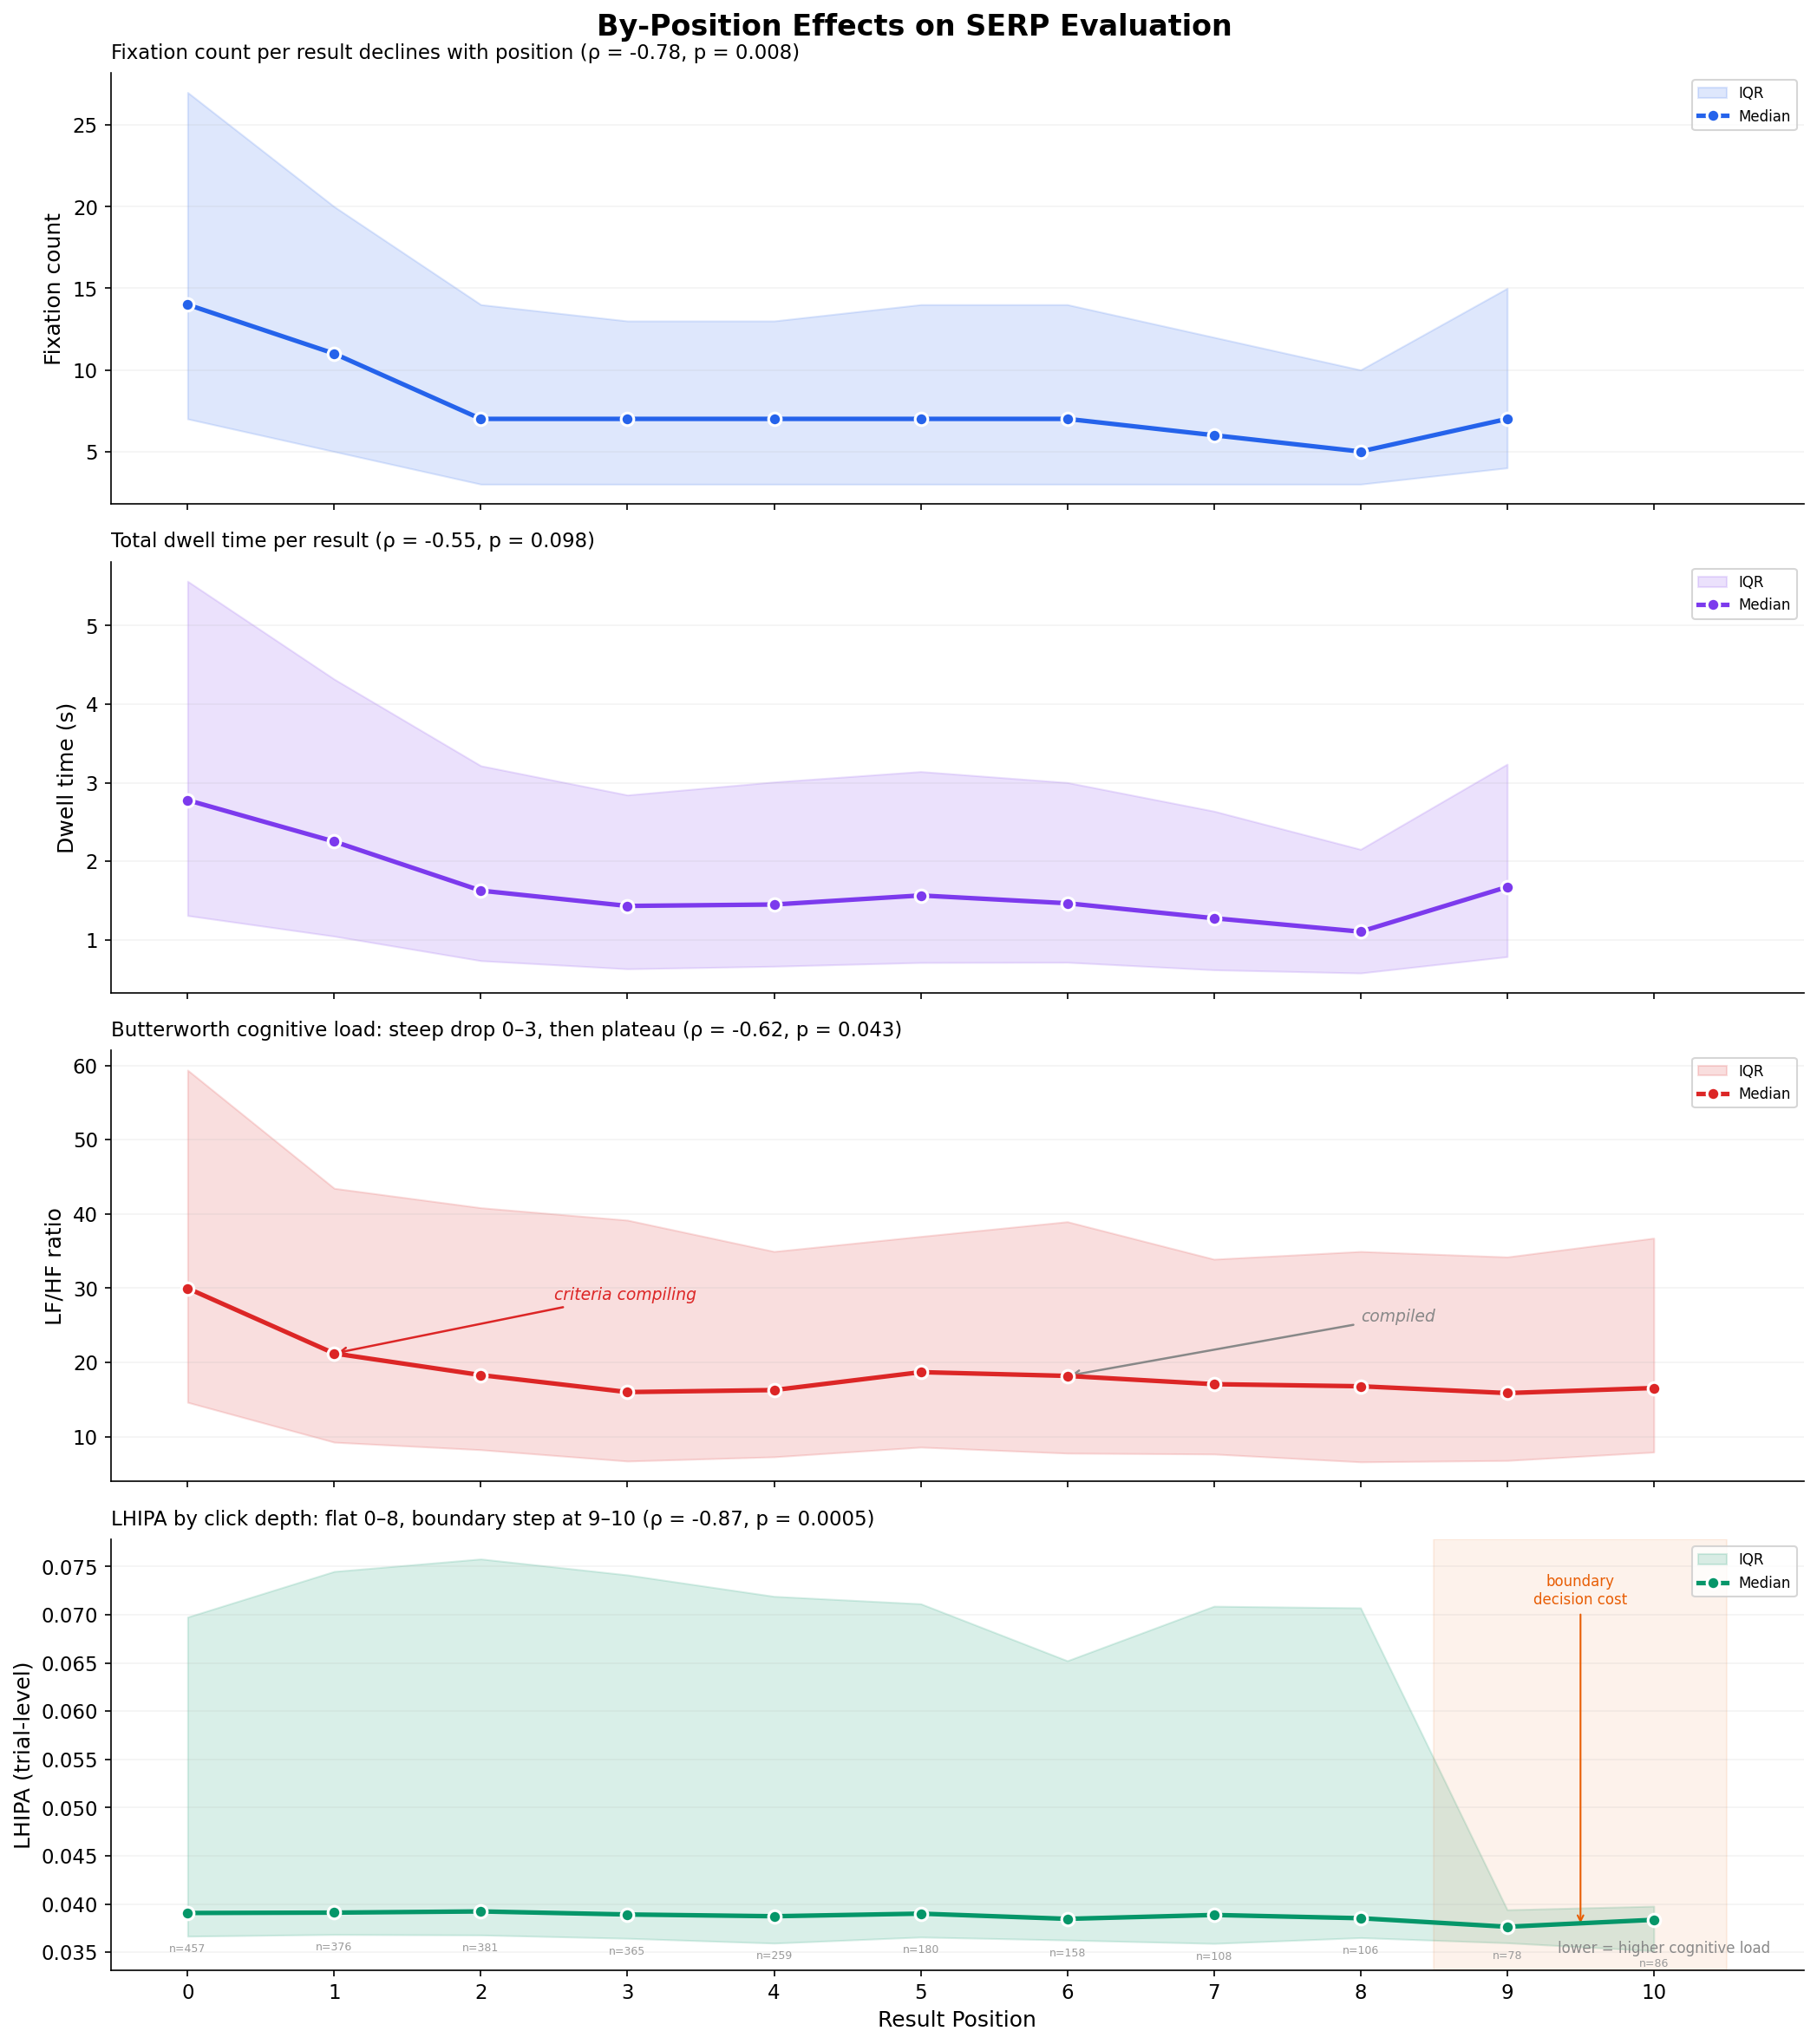

In [5]:
# ── Publication-quality rank effects figure ────────────────────────────
# Line plots with IQR shading. Shows shape + variance at each position.

from scipy.stats import bootstrap

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
fig.suptitle('By-Position Effects on SERP Evaluation', fontsize=16, fontweight='bold', y=0.98)

COLORS = {'fix': '#2563eb', 'dwell': '#7c3aed', 'bw': '#dc2626', 'lhipa': '#059669'}

# ── Compute per-position distributions ─────────────────────────────────

def pos_stats(values_by_pos, positions):
    """Compute median, IQR, and sample sizes for each position."""
    meds, q25s, q75s, ns = [], [], [], []
    for p in positions:
        vals = values_by_pos[p]
        if vals:
            arr = np.array(vals)
            meds.append(np.median(arr))
            q25s.append(np.percentile(arr, 25))
            q75s.append(np.percentile(arr, 75))
            ns.append(len(arr))
        else:
            meds.append(np.nan)
            q25s.append(np.nan)
            q75s.append(np.nan)
            ns.append(0)
    return np.array(meds), np.array(q25s), np.array(q75s), np.array(ns)

# Fixation count distributions
fc_by_pos = defaultdict(list)
dw_by_pos = defaultdict(list)
for r in eval_rows:
    fc_by_pos[r['position']].append(r['fix_count'])
    dw_by_pos[r['position']].append(r['fix_total_ms'] / 1000)

fc_med, fc_q25, fc_q75, fc_n = pos_stats(fc_by_pos, fix_positions)
dw_med, dw_q25, dw_q75, dw_n = pos_stats(dw_by_pos, fix_positions)
bw_med, bw_q25, bw_q75, bw_n = pos_stats(bw_pos_values, all_positions)

lh_by_pos = lhipa_by_click_pos
lh_med, lh_q25, lh_q75, lh_n = pos_stats(lh_by_pos, all_positions)

def plot_panel(ax, positions, med, q25, q75, n, color, ylabel, title, annotate_n=False):
    pos = np.array(positions)
    mask = ~np.isnan(med)
    p, m, lo, hi = pos[mask], med[mask], q25[mask], q75[mask]
    
    ax.fill_between(p, lo, hi, alpha=0.15, color=color, label='IQR')
    ax.plot(p, m, 'o-', color=color, linewidth=2.5, markersize=7, markeredgecolor='white',
            markeredgewidth=1.5, zorder=5, label='Median')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=11, loc='left', pad=8)
    ax.legend(fontsize=8, loc='upper right')
    
    if annotate_n:
        for pi, ni in zip(p, n[mask]):
            ax.annotate(f'n={int(ni)}', xy=(pi, lo[list(p).index(pi)]),
                       fontsize=6, color='#999', ha='center', va='top',
                       xytext=(0, -4), textcoords='offset points')

# ── Panel 1: Fixation count ───────────────────────────────────────────
rho, p_val = spearmanr(fix_positions, fc_med)
plot_panel(axes[0], fix_positions, fc_med, fc_q25, fc_q75, fc_n,
           COLORS['fix'], 'Fixation count',
           f'Fixation count per result declines with position (\u03c1 = {rho:.2f}, p = {p_val:.3f})')

# ── Panel 2: Dwell time ───────────────────────────────────────────────
rho, p_val = spearmanr(fix_positions, dw_med)
plot_panel(axes[1], fix_positions, dw_med, dw_q25, dw_q75, dw_n,
           COLORS['dwell'], 'Dwell time (s)',
           f'Total dwell time per result (\u03c1 = {rho:.2f}, p = {p_val:.3f})')

# ── Panel 3: Butterworth LF/HF ────────────────────────────────────────
rho, p_val = spearmanr(
    [p for p in all_positions if not np.isnan(bw_med[p])],
    [bw_med[p] for p in all_positions if not np.isnan(bw_med[p])])
plot_panel(axes[2], all_positions, bw_med, bw_q25, bw_q75, bw_n,
           COLORS['bw'], 'LF/HF ratio',
           f'Butterworth cognitive load: steep drop 0\u20133, then plateau (\u03c1 = {rho:.2f}, p = {p_val:.3f})')
axes[2].annotate('criteria compiling', xy=(1, bw_med[1]), fontsize=9,
                color='#dc2626', fontstyle='italic',
                xytext=(2.5, bw_med[0] * 0.95),
                arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.2))
axes[2].annotate('compiled', xy=(6, bw_med[6]), fontsize=9,
                color='#888', fontstyle='italic',
                xytext=(8, bw_med[0] * 0.85),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.2))

# ── Panel 4: LHIPA by click position ──────────────────────────────────
rho_all, p_all = spearmanr(
    [p for p in all_positions if not np.isnan(lh_med[p])],
    [lh_med[p] for p in all_positions if not np.isnan(lh_med[p])])
plot_panel(axes[3], all_positions, lh_med, lh_q25, lh_q75, lh_n,
           COLORS['lhipa'], 'LHIPA (trial-level)',
           f'LHIPA by click depth: flat 0\u20138, boundary step at 9\u201310 (\u03c1 = {rho_all:.2f}, p = {p_all:.4f})',
           annotate_n=True)
axes[3].set_xlabel('Result Position', fontsize=12)
axes[3].annotate('lower = higher cognitive load', xy=(0.98, 0.04),
                xycoords='axes fraction', fontsize=8, ha='right', color='#888')

# Highlight the boundary step
axes[3].axvspan(8.5, 10.5, alpha=0.08, color='#e85d04')
axes[3].annotate('boundary\ndecision cost', xy=(9.5, lh_med[9]),
                fontsize=8, color='#e85d04', ha='center',
                xytext=(9.5, lh_q75[5]),
                arrowprops=dict(arrowstyle='->', color='#e85d04', lw=1))

for ax in axes:
    ax.set_xticks(all_positions)
    ax.grid(axis='y', alpha=0.15)

plt.tight_layout()
plt.savefig('plot_rank_effects_hero.png', dpi=200, bbox_inches='tight')
plt.show()

## Forward-only vs regression fixations by position

The fixation count and dwell time panels above lump together two different kinds of attention:

- **Forward-pass fixations** — the user is seeing this result for the first time (scroll high-water mark is advancing)
- **Regression fixations** — the user scrolled back up to re-examine this result

These tell different stories. Forward-pass time should show the compiled-criteria effect
(declining effort at later positions). Regression time concentrates at the top
(positions 0–4 absorb 87% of regression targets). Lumping them muddies both signals.

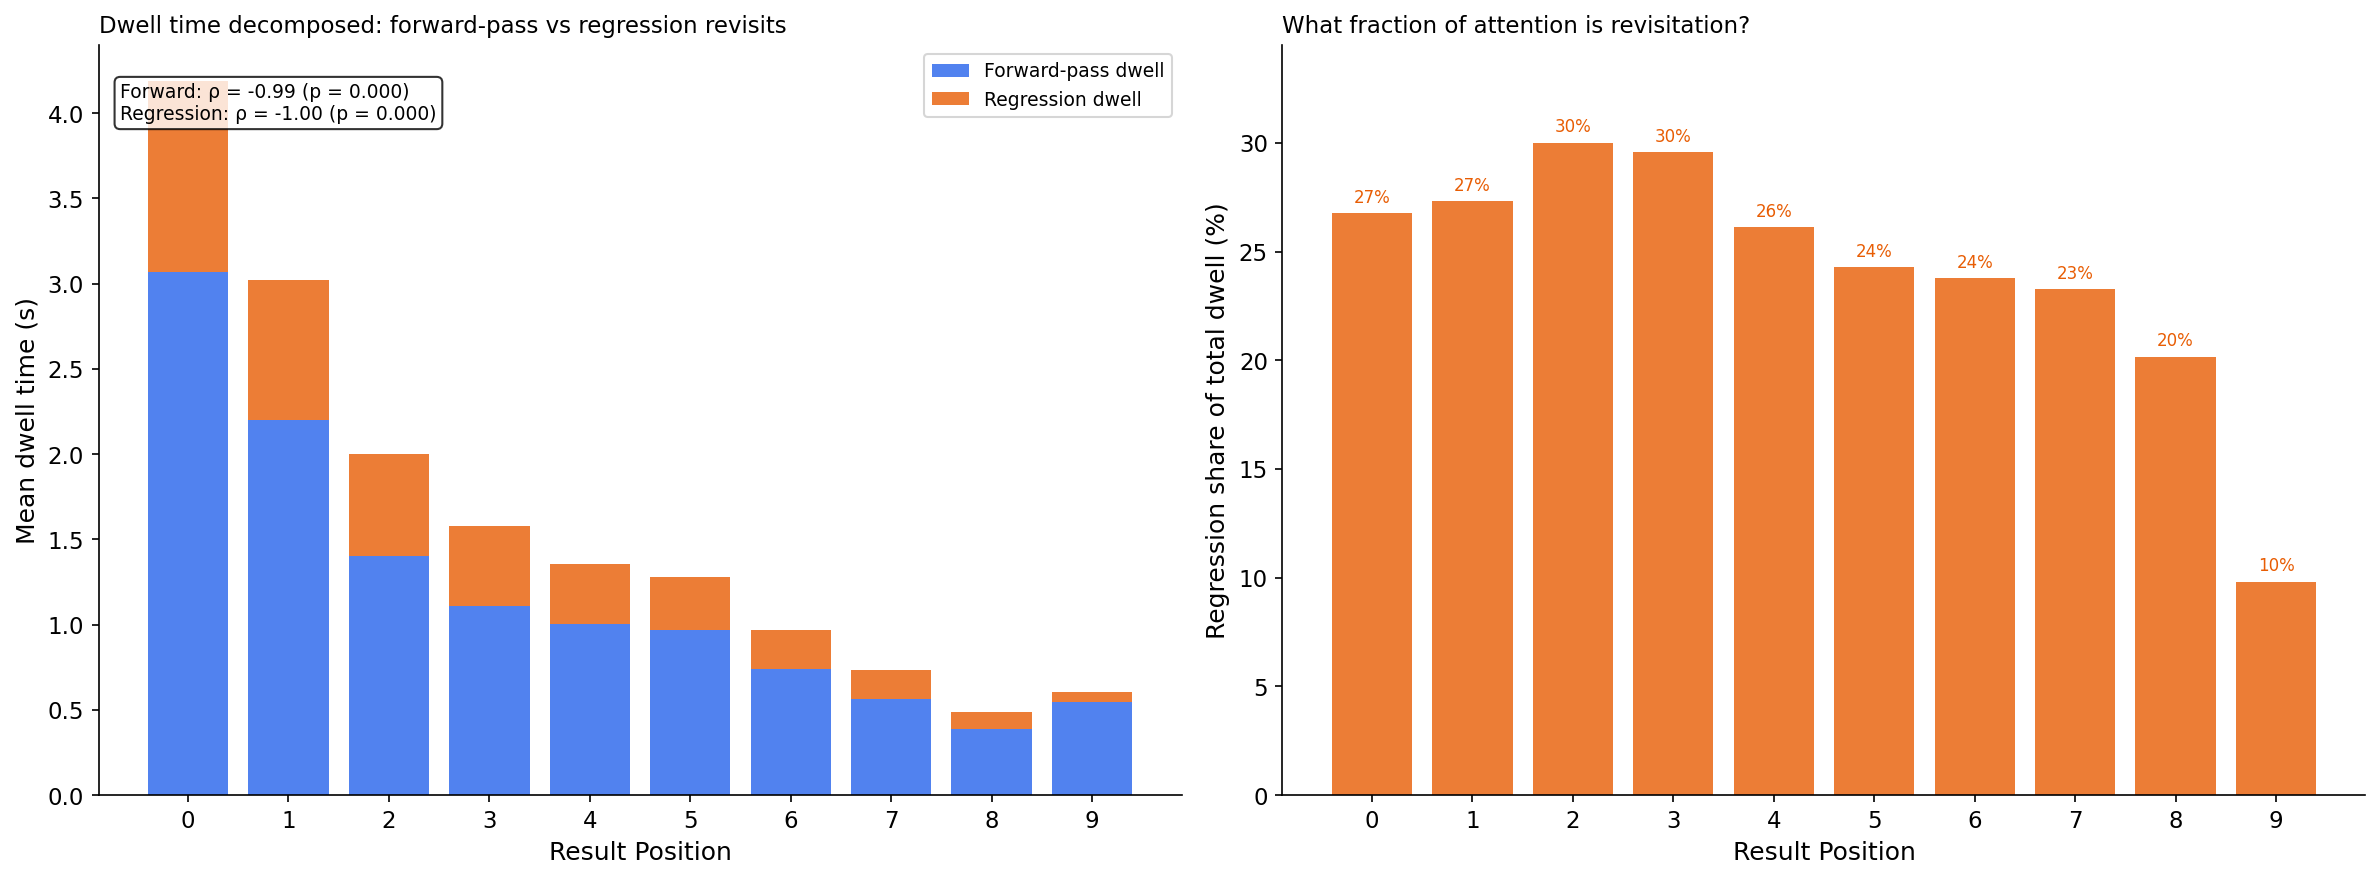


Forward vs Regression dwell by position:
 Pos  Forward(s)  Regress(s)  Total(s)   Reg%
--------------------------------------------------
   0        3.07        1.12      4.19  26.8%
   1        2.20        0.83      3.02  27.3%
   2        1.40        0.60      2.00  30.0%
   3        1.11        0.47      1.58  29.6%
   4        1.00        0.35      1.36  26.1%
   5        0.97        0.31      1.28  24.3%
   6        0.74        0.23      0.97  23.8%
   7        0.56        0.17      0.74  23.3%
   8        0.39        0.10      0.49  20.2%
   9        0.55        0.06      0.61   9.8%


In [6]:
# ── Forward vs regression fixation decomposition by position ──────────
# Classify each fixation as forward-pass or regression based on whether
# the scroll position has retreated from its high-water mark.

fwd_dwell_by_pos = defaultdict(list)  # per-trial forward dwell at each position
reg_dwell_by_pos = defaultdict(list)  # per-trial regression dwell at each position

for tid in trial_ids:
    t = load_trial(tid)
    if t is None:
        continue

    fixations = t['fixations']
    scr_h = t['screen_height']
    doc_h = t['doc_height']
    sts = t['scroll_ts']
    sys_ = t['scroll_ys']

    bands = result_bands(10, doc_h)
    tops = [b[0] for b in bands]

    # Track scroll high-water mark over time
    # A fixation is 'forward' if current scroll >= (hwm - small tolerance)
    fwd_by_pos = defaultdict(float)
    reg_by_pos = defaultdict(float)
    hwm = 0.0  # scroll high-water mark

    for fix in fixations:
        # Get scroll offset at fixation time
        so = 0.0
        if sts:
            if fix['t'] <= sts[0]: so = sys_[0]
            elif fix['t'] >= sts[-1]: so = sys_[-1]
            else: so = sys_[bisect_right(sts, fix['t']) - 1]

        # Update high-water mark
        if so > hwm:
            hwm = so

        # Classify: forward if within 50px of high-water mark, else regression
        is_forward = (so >= hwm - 50)

        # Map fixation to result position
        fy = max(0.0, min(fix['y'], scr_h))
        page_y = fy + so
        pos = bisect_right(tops, page_y) - 1
        if 0 <= pos <= 9:
            if is_forward:
                fwd_by_pos[pos] += fix['d']
            else:
                reg_by_pos[pos] += fix['d']

    for pos in range(10):
        fwd_dwell_by_pos[pos].append(fwd_by_pos.get(pos, 0) / 1000)  # seconds
        reg_dwell_by_pos[pos].append(reg_by_pos.get(pos, 0) / 1000)

# Compute means
fwd_means = [np.mean(fwd_dwell_by_pos[p]) for p in fix_positions]
reg_means = [np.mean(reg_dwell_by_pos[p]) for p in fix_positions]
total_means_check = [f + r for f, r in zip(fwd_means, reg_means)]
reg_share = [100 * r / (f + r) if (f + r) > 0 else 0 for f, r in zip(fwd_means, reg_means)]

# ── Stacked bar chart ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: stacked dwell time
ax1.bar(fix_positions, fwd_means, color='#2563eb', alpha=0.8, label='Forward-pass dwell', edgecolor='none')
ax1.bar(fix_positions, reg_means, bottom=fwd_means, color='#e85d04', alpha=0.8,
        label='Regression dwell', edgecolor='none')
ax1.set_xlabel('Result Position', fontsize=12)
ax1.set_ylabel('Mean dwell time (s)', fontsize=12)
ax1.set_title('Dwell time decomposed: forward-pass vs regression revisits',
              fontsize=11, loc='left')
ax1.legend(fontsize=9)
ax1.set_xticks(fix_positions)

# Annotate forward-only trend
rho_fwd, p_fwd = spearmanr(fix_positions, fwd_means)
rho_reg, p_reg = spearmanr(fix_positions, reg_means)
ax1.text(0.02, 0.95, f'Forward: \u03c1 = {rho_fwd:.2f} (p = {p_fwd:.3f})\n'
         f'Regression: \u03c1 = {rho_reg:.2f} (p = {p_reg:.3f})',
         transform=ax1.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Right: regression share
ax2.bar(fix_positions, reg_share, color='#e85d04', alpha=0.8, edgecolor='none')
ax2.set_xlabel('Result Position', fontsize=12)
ax2.set_ylabel('Regression share of total dwell (%)', fontsize=12)
ax2.set_title('What fraction of attention is revisitation?', fontsize=11, loc='left')
ax2.set_xticks(fix_positions)
ax2.set_ylim(0, max(reg_share) * 1.15)

for i, (p, rs) in enumerate(zip(fix_positions, reg_share)):
    ax2.text(p, rs + 0.5, f'{rs:.0f}%', ha='center', fontsize=8, color='#e85d04')

plt.tight_layout()
plt.savefig('plot_rank_effects_fwd_reg.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nForward vs Regression dwell by position:')
print(f'{"Pos":>4} {"Forward(s)":>11} {"Regress(s)":>11} {"Total(s)":>9} {"Reg%":>6}')
print('-' * 50)
for p in fix_positions:
    print(f'{p:>4} {fwd_means[p]:>11.2f} {reg_means[p]:>11.2f} {total_means_check[p]:>9.2f} {reg_share[p]:>5.1f}%')

## The dissociation that matters

The traditional reading of SERP rank effects is "declining effort" — users care less about
lower results, so they spend less time on them. That framing treats time as a proxy for effort.

The Butterworth data breaks that assumption. Cognitive load (LF/HF ratio) and time spent move
in **opposite directions**:

- **Time decreases** with position (fewer fixations, less total dwell)
- **Load per fixation decreases** with position (LF/HF drops steeply through positions 0–3)

Wait — both decrease? That sounds like the traditional story. But look at what's happening
*within* the timeline of a single trial:

- At position 0, the user is doing the hardest cognitive work: building evaluation criteria
  from scratch. What makes a good result? What are the important attributes? This is framework
  construction, and it's expensive.
- By position 3–4, the criteria are compiled. The user now knows what they're looking for.
  Each subsequent result is evaluated against a well-formed standard. Less cognitive effort
  is needed because the comparison framework already exists.
- Less time is needed because fewer fixations suffice when you know what to look for.

This is **framework compilation**, not declining interest. The user becomes an expert
evaluator *within a single SERP scan*.

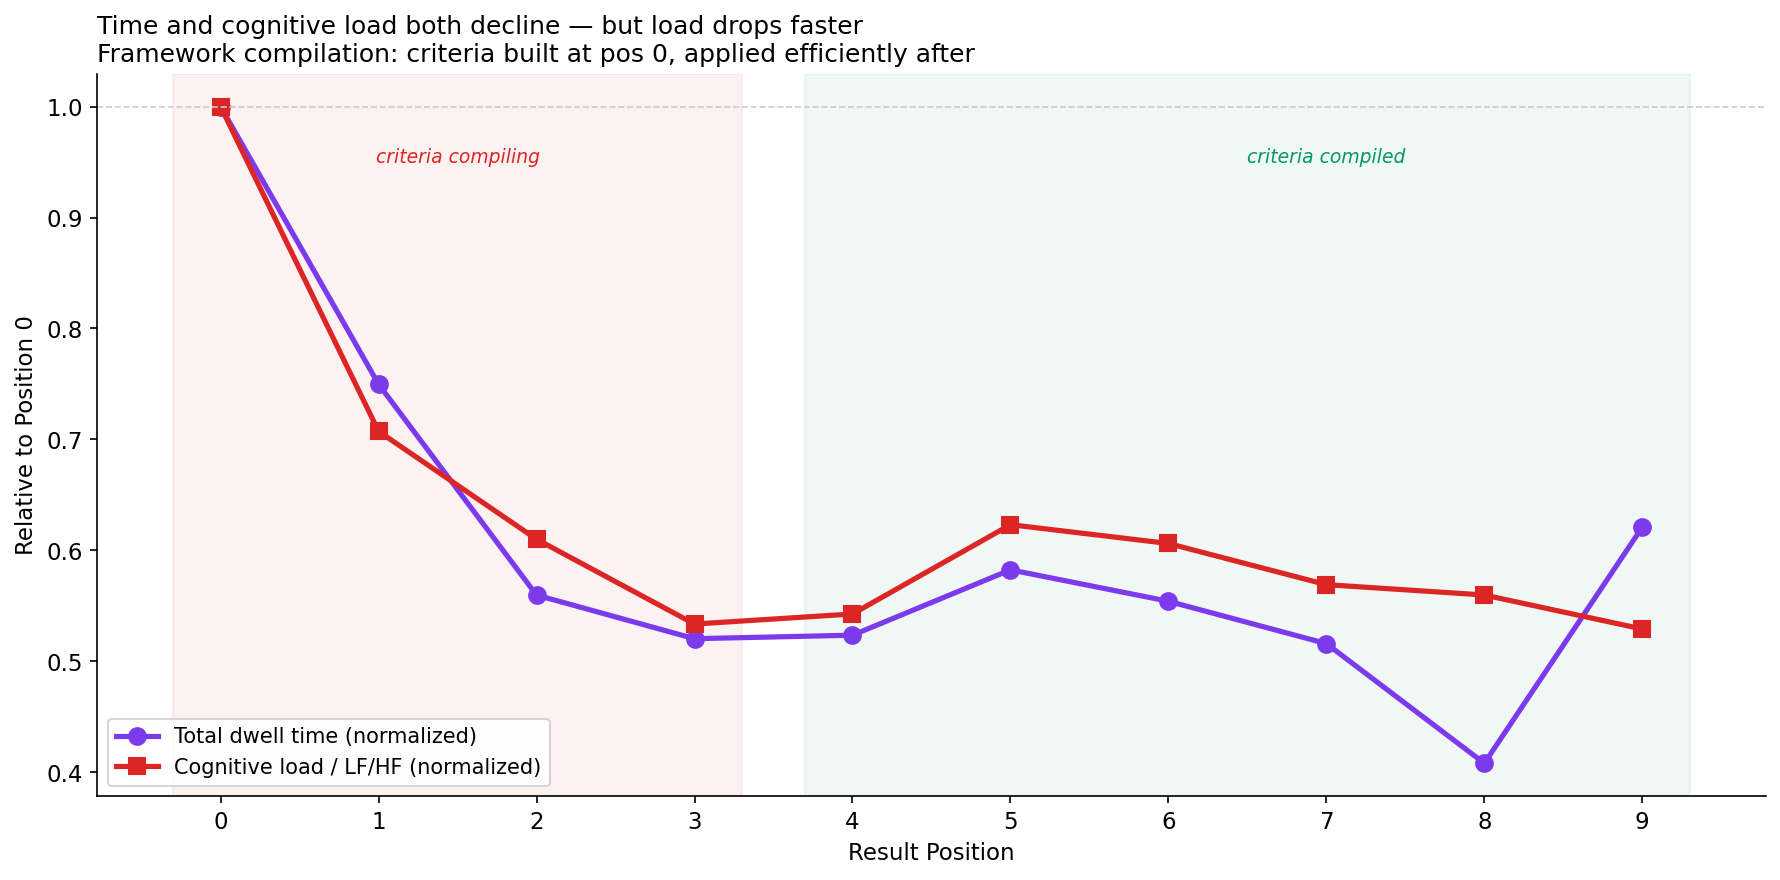

In [7]:
# ── Dissociation plot: time vs cognitive load ──────────────────────────
# Normalize both to position 0 = 1.0 so they're comparable on one axis.
# Restrict to positions 0–9 where both measures exist.

common_pos = [p for p in fix_positions if bw_pos_values[p]]

dwell_at_pos = {p: np.mean([r['fix_total_ms'] for r in eval_rows if r['position'] == p])
                for p in common_pos}
bw_at_pos = {p: np.median(bw_pos_values[p]) for p in common_pos}

dwell_norm = [dwell_at_pos[p] / dwell_at_pos[common_pos[0]] for p in common_pos]
bw_norm = [bw_at_pos[p] / bw_at_pos[common_pos[0]] for p in common_pos]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(common_pos, dwell_norm, 'o-', color='#7c3aed', linewidth=2.5, markersize=8,
        label='Total dwell time (normalized)')
ax.plot(common_pos, bw_norm, 's-', color='#dc2626', linewidth=2.5, markersize=8,
        label='Cognitive load / LF/HF (normalized)')
ax.axhline(1.0, color='#ccc', linestyle='--', linewidth=0.8)
ax.set_xlabel('Result Position')
ax.set_ylabel('Relative to Position 0')
ax.set_title('Time and cognitive load both decline — but load drops faster\n'
             'Framework compilation: criteria built at pos 0, applied efficiently after',
             fontsize=12, loc='left')
ax.set_xticks(common_pos)
ax.legend(fontsize=10)

# Annotate the steep drop zone
ax.axvspan(-0.3, 3.3, alpha=0.06, color='#dc2626')
ax.text(1.5, max(dwell_norm) * 0.95, 'criteria compiling',
        ha='center', fontsize=9, color='#dc2626', fontstyle='italic')
ax.axvspan(3.7, max(common_pos) + 0.3, alpha=0.06, color='#059669')
ax.text(7, max(dwell_norm) * 0.95, 'criteria compiled',
        ha='center', fontsize=9, color='#059669', fontstyle='italic')

plt.tight_layout()
plt.savefig('plot_rank_effects_dissociation.png', dpi=200, bbox_inches='tight')
plt.show()

## How this connects to the rest of the project

- **Ski-jump (notebook 00):** The boundary uptick at position 10 is where compiled criteria
  meet zero travel cost. The user has seen everything, knows exactly what they want, and the
  cost of evaluating one more result is near zero.

- **Priming null (notebook 08):** Query-result semantic similarity is too flat across positions
  to drive the rank effect. The decline in time is not about content — it's about the user's
  evolving comparison framework.

- **Survey phase (notebook 13):** The survey phase (wide saccades, pupil constriction) happens
  primarily at positions 0–2. This is where framework compilation occurs. The evaluate phase
  (narrow reading saccades) dominates at later positions — criteria are compiled, now just applying them.

- **Regressions (notebooks 07a-c):** When compiled criteria produce a close call, the user
  regresses to re-evaluate. Confirmation regressions (+32% fixations) are the compiled framework
  being stress-tested. Rejection regressions (-17%) are quick eliminations — compiled criteria
  make rejection fast.

- **LHIPA (notebook 05):** Trial-level LHIPA captures the *total* cognitive investment across
  a trial. Deeper clicks require more comparisons, hence lower LHIPA. Butterworth captures the
  *per-position* trajectory — they measure load at different timescales.

## Summary table

| Measure | Trend with position | Spearman \u03c1 | Interpretation |
|---------|--------------------|-----------|---------|
| Click share | Declining (+ boundary uptick) | — | Attention allocation under diminishing returns |
| Fixation count | Declining | see above | Fewer samples taken |
| Total dwell time | Declining | see above | Less total time invested |
| Butterworth LF/HF | Declining (steep 0–3, plateau) | see above | Cognitive effort peaks during framework construction |
| LHIPA (by click depth) | Declining | see above | Deeper foraging = more cumulative comparison work |

**One sentence:** Users build evaluation criteria at the top of the SERP and apply them
with increasing efficiency as they scan down — spending less time *and* less cognitive effort
per result, because the comparison framework is already compiled.